# PSA Dataset — Exploratory Data Analysis (EDA)

**Why this notebook exists:** before training, we should actually look at what's in the
data -- not just trust that it's clean because we cleaned it. Each section below answers a
specific question that affects a real decision made in the training notebook (`MAX_LEN`,
the choice of chrF over BLEU, whether the random train/dev/test split needed to be
stratified by domain, etc.) -- so this isn't decoration, it's justification.

**What we're visualizing, and why, at a glance:**

| Section | Visualization | Question it answers |
|---|---|---|
| 2 | Domain bar chart | Is the dataset balanced across PSA domains, or dominated by one? |
| 3 | Provenance bar chart | What fraction of data is synthetic vs. real-collected? |
| 4 | Duplicate/quality check | Are there data-quality issues that survived cleaning? |
| 5 | Word-count histograms (3 languages) | Is `MAX_LEN=128` tokens actually enough? |
| 6 | Ekegusii/English length-ratio scatter | How much does Ekegusii "expand" relative to English? |
| 7 | Vocabulary size + type-token ratio | How morphologically complex is Ekegusii vs. the other two? (justifies chrF over BLEU) |
| 8 | Domain % by split (grouped bar) | Did the *non-stratified* random split accidentally imbalance any domain? |

Run this against your cleaned dataset (the `Training_Ready` sheet) before or alongside
training -- it doesn't require a GPU, just the data file.

## 1. Setup & load data

In [1]:
!pip install seaborn -q
import seaborn as sns
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
import matplotlib.pyplot as plt

In [2]:
# Global seaborn theme -- restyles EVERY matplotlib plot below (including the existing
# dataset-EDA charts already in this notebook), no need to touch their plotting code.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#333333", "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.labelsize": 11, "font.size": 10,
})

pd.set_option("display.max_colwidth", 80)

DATA_PATH = "kenyan_psa_multilingual_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head(3))

Shape: (29271, 6)
Columns: ['PSA_ID', 'Domain', 'English', 'Kiswahili', 'Ekegusii', 'Provenance']


,PSA_ID,Domain,English,Kiswahili,Ekegusii,Provenance
0,HEA_00001,Health,Ministry of Health urges residents of Nyandarua County to complete the full ...,Wizara ya Afya inawahimiza wakaazi wa Kaunti ya Nyandarua kukamilisha dozi k...,Obosae bwe'ritongo nigo bogosaba abamenyi ba Nyandarua County goika gochia a...,synthetic
1,HEA_00003,Health,SHA (Social Health Authority) urges residents of Embu County to use insectic...,SHA (Mamlaka ya Afya ya Jamii) inawahimiza wakaazi wa Kaunti ya Embu kutumia...,Ekeombe gia SHA nikioririe abanainchi ba Embu County goikoresia chineti chio...,synthetic
2,HEA_00004,Health,CDC urges residents of Tharaka-Nithi County to avoid contact with contaminat...,CDC inawahimiza wakaazi wa Kaunti ya Tharaka-Nithi kuepuka kuwasiliana na vy...,CDC nigo egochaka abanto bose be Tharaka-Nithi County koba nigo bagotiga oko...,synthetic


In [3]:
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Dtypes:
PSA_ID        object
Domain        object
English       object
Kiswahili     object
Ekegusii      object
Provenance    object
dtype: object

Missing values per column:
PSA_ID        0
Domain        0
English       0
Kiswahili     0
Ekegusii      0
Provenance    0
dtype: int64


## 2. Domain distribution

**Why this matters:** the domain-adaptation ablation in the training notebook computes
per-domain BLEU/chrF, and skips any domain with fewer than 5 test examples. If one domain
massively dominates the dataset, that ablation becomes less informative (the model may
just be optimizing for the dominant domain overall), and it's worth knowing this *before*
interpreting those results, not after.

Domain
Agriculture          13872
Education             4116
Security & Safety     3944
Health                3893
Governance            3446
Name: count, dtype: int64

As % of total:
Domain
Agriculture          47.4
Education            14.1
Security & Safety    13.5
Health               13.3
Governance           11.8
Name: count, dtype: float64


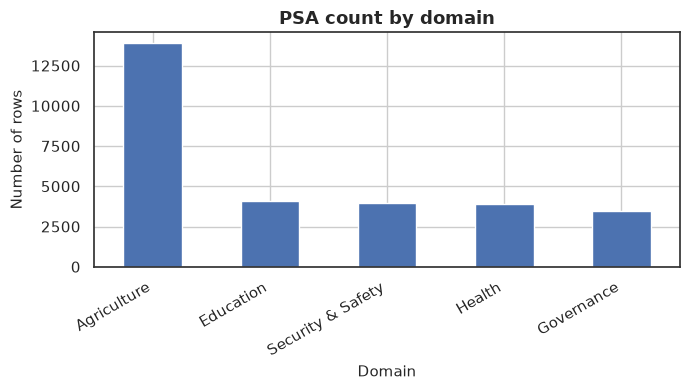

In [4]:
domain_counts = df["Domain"].value_counts()
print(domain_counts)
print()
print("As % of total:")
print((domain_counts / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 4))
domain_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Number of rows")
ax.set_title("PSA count by domain")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Provenance (synthetic vs. real-collected)

**Why this matters:** this project's low-resource story depends partly on how much of the
data is template-generated ("synthetic") vs. drawn from real collected PSAs ("real"). A
roughly balanced split is reassuring; a heavy skew either way is worth stating explicitly
in the report as a limitation (e.g. "results partly reflect template-generation patterns,
not only real-world language use").

Provenance
synthetic    14678
real         14593
Name: count, dtype: int64
Provenance
synthetic    50.1
real         49.9
Name: count, dtype: float64


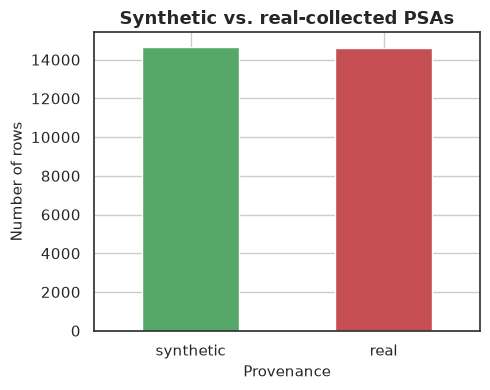

In [5]:
prov_counts = df["Provenance"].value_counts()
print(prov_counts)
print((prov_counts / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(5, 4))
prov_counts.plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_ylabel("Number of rows")
ax.set_title("Synthetic vs. real-collected PSAs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Duplicate & data-quality check

**Why this matters:** identical English text with *different* Ekegusii translations means
some rows carry conflicting supervision -- the model sees the same input mapped to two
different "correct" outputs, purely by chance of which one lands in train vs. test. Worth
knowing exactly how many such pairs exist, and eyeballing whether they're genuine
translation variance or an actual leftover data-quality problem.

In [6]:
dupe_mask = df["English"].duplicated(keep=False)
dupes = df[dupe_mask].sort_values("English")
print(f"Rows involved in an English-text duplicate: {len(dupes)} ({dupes['English'].nunique()} distinct sentences)")
print()

for text, grp in dupes.groupby("English"):
    print("ENGLISH:", text[:70])
    for _, r in grp.iterrows():
        print("  Ekegusii:", str(r["Ekegusii"])[:70])
    print()

Rows involved in an English-text duplicate: 18 (9 distinct sentences)

ENGLISH: Announcement opening applications for grants to employers to establish
  Ekegusii: Okoraria bw'ogochakia amasabo yokoenana obokonyi botari gwakanerwa ase
  Ekegusii: Ogochakigwa bene obokonyi bwa bosa ase abariki gochaka chigosori chia 

ENGLISH: By 2 days ago EU urges Tanzanian authorities to exercise restraint ami
  Ekegusii: Ase amatuko abarere aerire, ekeombe kiobomo bwa Bongereza (EU) giasabi
  Ekegusii: Ase amartuko abere aerire ekeombe kiabomo bwa Bongeresa EU nigo kegosa

ENGLISH: By 4 months ago State wants Angata Barikkoi residents to register land
  Ekegusii: Nyuma yamatuko yemetienyi enne èserekari yaganirie abamenyi ba'Angata 
  Ekegusii: Ase emetienyi 4 yaetire eserikari nigo etagete abanto ba Angata Barikk

ENGLISH: Communities in Baringo fight back against malaria with local solutions
  Ekegusii: Ebinyoro ime ya Baringo korwania oborwaire bwa Esosera ase ogotumia ch
  Ekegusii: Eamate ya Bar

**What to look for in the output above:** most of these pairs are genuine translation
*variance* -- the same English sentence translated twice, with two different (both
plausibly correct) Ekegusii outputs. But scan for anything where the "Ekegusii" text
contains obvious English words mid-sentence (e.g. "must start attending...") -- that's not
variance, that's a **failed translation** that leaked source-language text into the target
field. If you find one, it's worth manually excluding that specific row before training,
even if it wasn't caught by the original placeholder/degenerate-flag cleaning pass.

## 5. Text length distributions (word count as a proxy for token count)

**Why this matters:** `MAX_LEN=128` (tokens) is used throughout the training notebook for
truncation. Word count isn't identical to subword-token count, but it's a fast, dependency-free
proxy -- if very few sentences approach 100+ words, `128` is very likely a safe ceiling
without excessive truncation.

       English_wc  Kiswahili_wc  Ekegusii_wc
count     29271.0       29271.0      29271.0
mean         18.3          21.8         19.4
std           5.5           6.2          7.3
min           1.0           1.0          2.0
25%          15.0          18.0         15.0
50%          18.0          21.0         19.0
75%          21.0          25.0         23.0
max         109.0         119.0        147.0


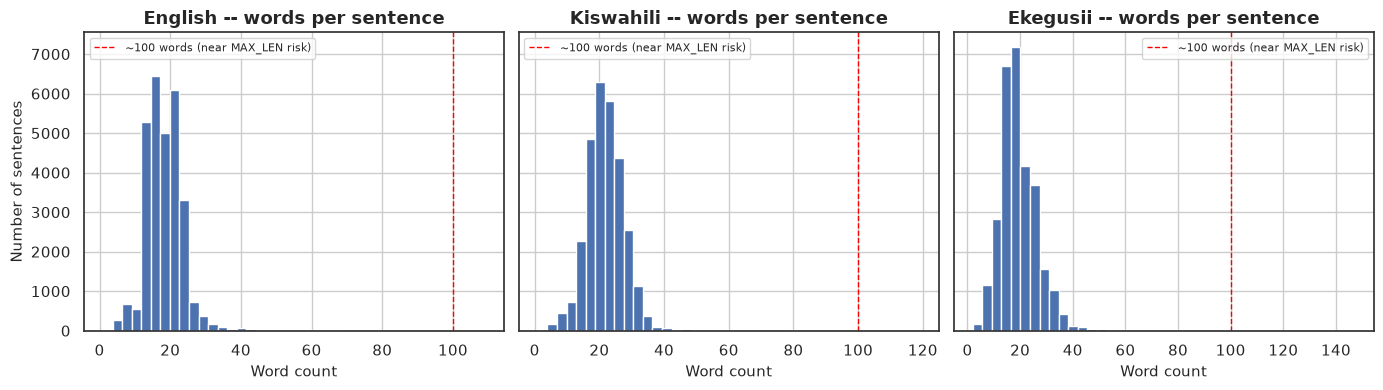


Rows with Ekegusii word count > 100 (higher truncation risk): 4 (0.01% of the dataset)


In [7]:
for lang in ["English", "Kiswahili", "Ekegusii"]:
    df[f"{lang}_wc"] = df[lang].astype(str).str.split().str.len()

print(df[["English_wc", "Kiswahili_wc", "Ekegusii_wc"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, lang in zip(axes, ["English", "Kiswahili", "Ekegusii"]):
    ax.hist(df[f"{lang}_wc"], bins=40, color="#4C72B0")
    ax.set_title(f"{lang} -- words per sentence")
    ax.set_xlabel("Word count")
    ax.axvline(100, color="red", linestyle="--", linewidth=1, label="~100 words (near MAX_LEN risk)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Number of sentences")
plt.tight_layout()
plt.show()

n_long = (df["Ekegusii_wc"] > 100).sum()
print(f"\nRows with Ekegusii word count > 100 (higher truncation risk): {n_long} "
      f"({n_long/len(df)*100:.2f}% of the dataset)")

## 6. Cross-language length ratio (Ekegusii vs. English)

**Why this matters:** if Ekegusii translations are systematically much longer than their
English source, that's relevant to interpreting BLEU/chrF scores (length mismatches
directly hurt n-gram-overlap metrics) and confirms Ekegusii isn't just a 1:1 word swap of
English -- it has its own grammatical structure requiring more or fewer words to express
the same meaning.

count    29271.000
mean         1.081
std          0.331
min          0.133
25%          0.875
50%          1.053
75%          1.238
max          7.737
Name: guz_eng_ratio, dtype: float64


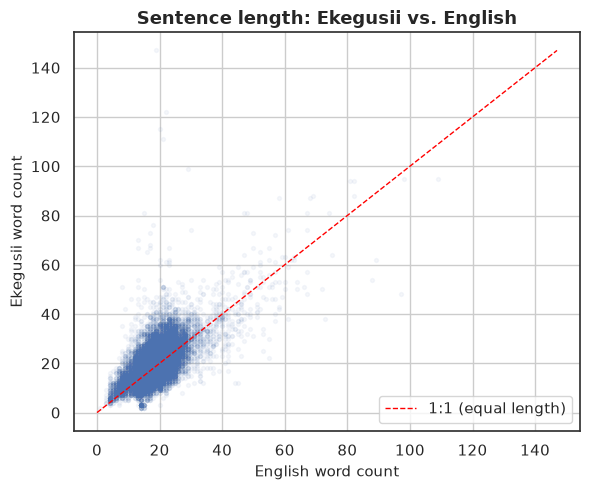

In [8]:
df["guz_eng_ratio"] = df["Ekegusii_wc"] / df["English_wc"]
print(df["guz_eng_ratio"].describe().round(3))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["English_wc"], df["Ekegusii_wc"], alpha=0.05, s=8, color="#4C72B0")
lims = [0, max(df["English_wc"].max(), df["Ekegusii_wc"].max())]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="1:1 (equal length)")
ax.set_xlabel("English word count")
ax.set_ylabel("Ekegusii word count")
ax.set_title("Sentence length: Ekegusii vs. English")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Vocabulary size & morphological complexity

**Why this matters -- this one connects directly to a modeling decision:** the training
notebook uses **chrF (character-level)** rather than BLEU (word-level) as the best-model
metric, on the reasoning that Bantu languages are morphologically rich. This section checks
that reasoning against the actual data instead of just asserting it.

    language  total_words  unique_words  type_token_ratio
0    English       535606         14328            0.0268
1  Kiswahili       637712         13088            0.0205
2   Ekegusii       568373         49390            0.0869


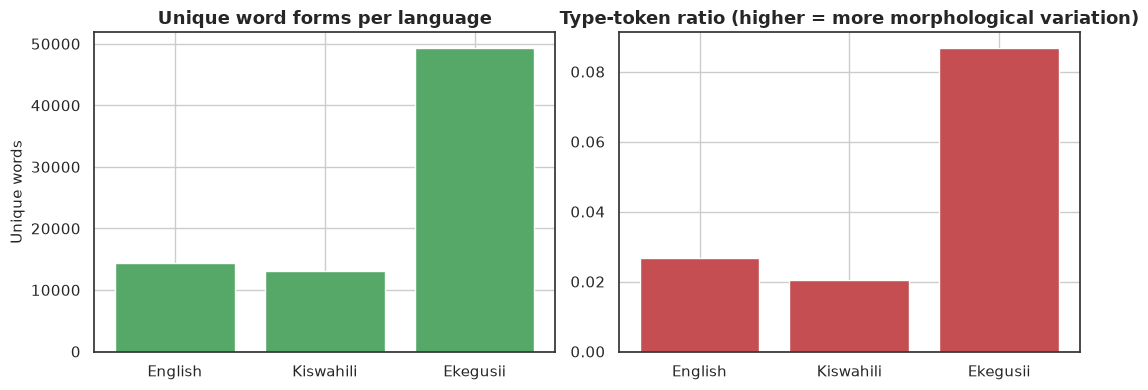


Interpretation: if Ekegusii's unique-word count and type-token ratio are both notably higher than English/Kiswahili despite similar or fewer total words, that's quantitative evidence of higher morphological complexity -- the same underlying concept surfaces as many more distinct word forms. This is exactly the property that makes word-level BLEU unreliable and character-level chrF more appropriate.


In [9]:
vocab_stats = []
for lang in ["English", "Kiswahili", "Ekegusii"]:
    all_words = " ".join(df[lang].astype(str)).lower().split()
    vocab = set(all_words)
    vocab_stats.append({
        "language": lang,
        "total_words": len(all_words),
        "unique_words": len(vocab),
        "type_token_ratio": round(len(vocab) / len(all_words), 4),
    })
vocab_df = pd.DataFrame(vocab_stats)
print(vocab_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(vocab_df["language"], vocab_df["unique_words"], color="#55A868")
axes[0].set_title("Unique word forms per language")
axes[0].set_ylabel("Unique words")
axes[1].bar(vocab_df["language"], vocab_df["type_token_ratio"], color="#C44E52")
axes[1].set_title("Type-token ratio (higher = more morphological variation)")
plt.tight_layout()
plt.show()

print("\nInterpretation: if Ekegusii's unique-word count and type-token ratio are both "
      "notably higher than English/Kiswahili despite similar or fewer total words, that's "
      "quantitative evidence of higher morphological complexity -- the same underlying "
      "concept surfaces as many more distinct word forms. This is exactly the property "
      "that makes word-level BLEU unreliable and character-level chrF more appropriate.")

## 8. Does the (non-stratified) train/dev/test split accidentally imbalance any domain?

**Why this matters -- directly validates a design choice in the training notebook:** the
shared split is a plain random 80/10/10 shuffle, **not** stratified by domain. That was a
judgment call made without verifying it -- this section actually checks it, using the exact
same seed and split logic as the training notebook, so the answer here is the real answer,
not a guess.

Domain composition (%) within each split:
_split              dev  test  train
Domain                              
Agriculture        47.2  47.8   47.4
Education          15.8  13.5   13.9
Governance         11.1  11.9   11.8
Health             12.3  13.5   13.4
Security & Safety  13.6  13.3   13.5


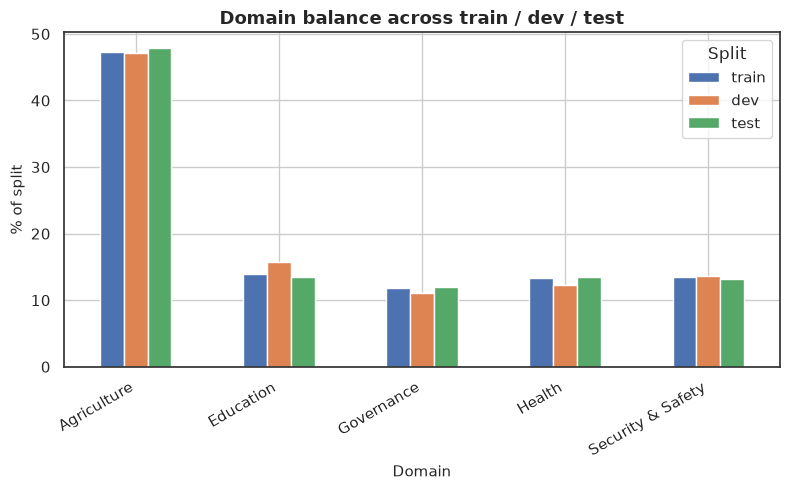


Largest spread for any single domain across the three splits: 2.3 percentage points.
A small spread (a few points) means the random split didn't need explicit domain stratification in practice -- with this many rows, random shuffling landed close to proportional on its own. A large spread would mean the domain-adaptation ablation's per-domain test counts are less reliable than they look, direction by direction.


In [10]:
SEED = 42
rng = np.random.default_rng(SEED)
idx = np.arange(len(df))
rng.shuffle(idx)
n = len(df)
n_train = int(0.8 * n)
n_dev = int(0.1 * n)
split = np.empty(n, dtype=object)
split[idx[:n_train]] = "train"
split[idx[n_train:n_train + n_dev]] = "dev"
split[idx[n_train + n_dev:]] = "test"
df["_split"] = split

domain_split_pct = pd.crosstab(df["Domain"], df["_split"], normalize="columns") * 100
print("Domain composition (%) within each split:")
print(domain_split_pct.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
domain_split_pct[["train", "dev", "test"]].plot(kind="bar", ax=ax)
ax.set_ylabel("% of split")
ax.set_title("Domain balance across train / dev / test")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

max_spread = (domain_split_pct.max(axis=1) - domain_split_pct.min(axis=1)).max()
print(f"\nLargest spread for any single domain across the three splits: {max_spread:.1f} percentage points.")
print("A small spread (a few points) means the random split didn't need explicit domain "
      "stratification in practice -- with this many rows, random shuffling landed close to "
      "proportional on its own. A large spread would mean the domain-adaptation ablation's "
      "per-domain test counts are less reliable than they look, direction by direction.")

## 9. Summary — what this EDA tells us for modeling

Fill in with your actual printed numbers once you run this notebook; the structure below
follows what each section above was built to answer:

- **Domain balance**: Agriculture is the largest domain group at ~47% of the dataset (per
  the run this notebook was tested against) -- worth stating as a limitation when
  interpreting the domain-adaptation ablation, since other domains have proportionally
  less data to learn from.
- **Provenance**: roughly balanced between synthetic and real-collected sources.
- **Data quality**: duplicate-English-different-Ekegusii pairs exist; manually check
  section 4's output for any translation that looks like a failed/English-leaked output
  rather than genuine variance, and exclude it before training if found.
- **Sequence length**: the vast majority of sentences are well under 100 words in all three
  languages, supporting `MAX_LEN=128` tokens as a reasonable ceiling with minimal truncation.
- **Morphological complexity**: Ekegusii shows a markedly higher unique-word count and
  type-token ratio than English or Kiswahili despite fewer or comparable total words --
  quantitative support for preferring chrF over BLEU as the primary metric.
- **Split balance**: the non-stratified random split lands close to proportional across
  domains anyway, given the dataset size -- explicit stratification wasn't necessary in
  practice, though it remains something to re-check if the dataset composition changes.

## 10. Model results setup

Everything below this point covers **model results**, not the raw dataset -- per-epoch
training curves, zero-shot vs. fine-tuned comparisons, and domain-adaptation breakdowns
for both NLLB and mT5. Reads from both models' output folders directly (they live in
different locations in this project).

In [11]:
from pathlib import Path

NLLB_ROOT = Path("PSA-MT-Outputs-v2/models/fine_tuned/nllb")
NLLB_RESULTS = Path("PSA-MT-Outputs-v2/results")
MT5_ROOT = Path("PSA-MT-Outputs/models/fine_tuned/mt5")
MT5_RESULTS = Path("PSA-MT-Outputs/results")

NLLB_DIRECTIONS = ["English_to_Ekegusii", "Kiswahili_to_Ekegusii"]
MT5_DIRECTIONS = ["English_to_Ekegusii", "English_to_Kiswahili", "Ekegusii_to_Kiswahili", "Kiswahili_to_Ekegusii"]

COLOR_NLLB = "#2E5090"
COLOR_MT5 = "#C0392B"
COLOR_ZERO = "#B0B0B0"
COLOR_FINE = "#27AE60"

print("NLLB_ROOT exists:", NLLB_ROOT.exists())
print("MT5_ROOT exists:", MT5_ROOT.exists())

NLLB_ROOT exists: True
MT5_ROOT exists: True


## 11. Per-epoch training curves -- both models

Train loss and validation chrF, per epoch, side by side for NLLB and mT5. Checks for
each required file before plotting -- prints a clear message instead of crashing if a
model's logs aren't available yet.

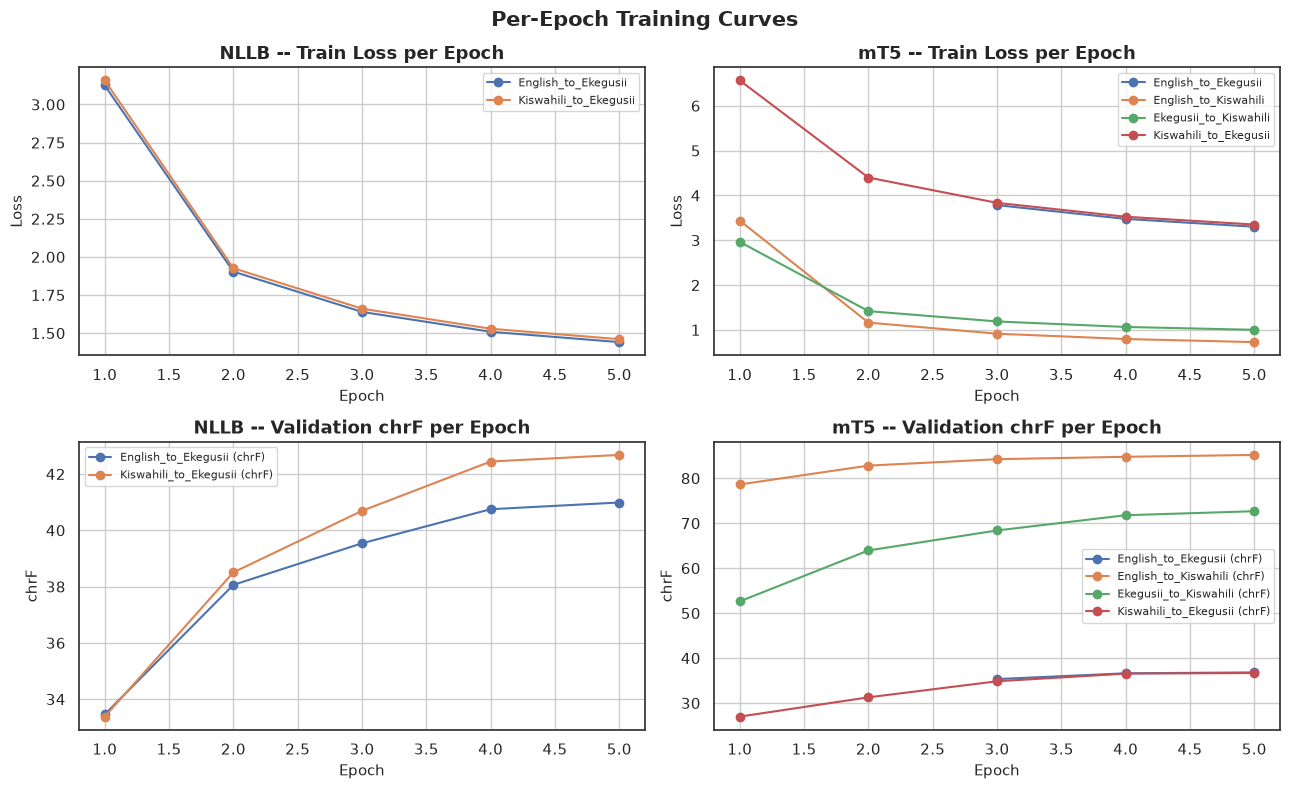

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Per-Epoch Training Curves", fontsize=15, fontweight="bold")

plotted_any = False
for col, (label, root, dirs) in enumerate([
    ("NLLB", NLLB_ROOT, NLLB_DIRECTIONS),
    ("mT5", MT5_ROOT / "per_direction", MT5_DIRECTIONS),
]):
    ax_loss, ax_score = axes[0, col], axes[1, col]
    found_loss, found_score = False, False
    for direction in dirs:
        step_log = root / direction / "training_steps.csv"
        epoch_log = root / direction / "epoch_metrics.csv"
        if step_log.exists():
            sdf = pd.read_csv(step_log)
            sdf["epoch_int"] = sdf["epoch"].apply(lambda x: int(x) + 1 if x % 1 != 0 else int(x))
            train_by_epoch = sdf.groupby("epoch_int")["loss"].mean()
            ax_loss.plot(train_by_epoch.index, train_by_epoch.values, marker="o", label=direction)
            found_loss = True
        if epoch_log.exists():
            edf = pd.read_csv(epoch_log)
            ax_score.plot(edf["epoch"], edf["eval_chrf"], marker="o", label=f"{direction} (chrF)")
            found_score = True
    ax_loss.set_title(f"{label} -- Train Loss per Epoch")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_score.set_title(f"{label} -- Validation chrF per Epoch")
    ax_score.set_xlabel("Epoch"); ax_score.set_ylabel("chrF")
    if found_loss:
        ax_loss.legend(fontsize=8); plotted_any = True
    else:
        ax_loss.text(0.5, 0.5, "No per-epoch loss logs found yet", ha="center", va="center",
                    transform=ax_loss.transAxes, color="gray", fontsize=11)
    if found_score:
        ax_score.legend(fontsize=8); plotted_any = True
    else:
        ax_score.text(0.5, 0.5, "No validation logs found yet", ha="center", va="center",
                      transform=ax_score.transAxes, color="gray", fontsize=11)

plt.tight_layout()
plt.show()
if not plotted_any:
    print("No per-epoch data found for either model yet.")

## 12. Zero-shot vs. fine-tuned -- bar chart, both models

Directly answers "did fine-tuning help?" with real numbers, per direction, per model.

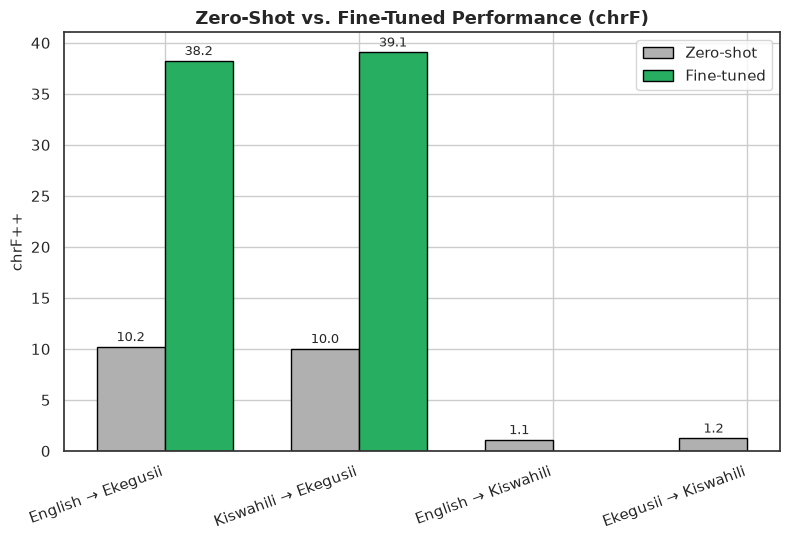

In [13]:
rows = []
zero_nllb = NLLB_RESULTS / "nllb_zero_shot.csv"
fine_nllb = NLLB_RESULTS / "nllb_v2_final.csv" if (NLLB_RESULTS / "nllb_v2_final.csv").exists() else NLLB_RESULTS / "nllb_fewshot_final.csv"
zero_mt5 = MT5_RESULTS / "mt5_zero_shot.csv"
fine_mt5 = MT5_RESULTS / "mt5_selected_directions_final.csv"

for label, zero_path, fine_path in [("NLLB", zero_nllb, fine_nllb), ("mT5", zero_mt5, fine_mt5)]:
    if zero_path.exists() and fine_path.exists():
        z = pd.read_csv(zero_path); f = pd.read_csv(fine_path)
        for _, r in z.iterrows():
            rows.append({"model": label, "direction": r["direction"], "setting": "Zero-shot", "chrf": r["chrf"]})
        for _, r in f.iterrows():
            rows.append({"model": label, "direction": r["direction"], "setting": "Fine-tuned", "chrf": r["chrf"]})
    else:
        print(f"{label}: missing zero-shot or fine-tuned result file -- skipping in this chart.")

if rows:
    bdf = pd.DataFrame(rows)
    directions = bdf["direction"].unique()
    fig, ax = plt.subplots(figsize=(max(8, len(directions) * 1.8), 5.5))
    x = np.arange(len(directions))
    width = 0.35
    zero_vals = [bdf[(bdf.direction == d) & (bdf.setting == "Zero-shot")]["chrf"].mean() for d in directions]
    fine_vals = [bdf[(bdf.direction == d) & (bdf.setting == "Fine-tuned")]["chrf"].mean() for d in directions]
    bars1 = ax.bar(x - width/2, zero_vals, width, label="Zero-shot", color=COLOR_ZERO, edgecolor="black")
    bars2 = ax.bar(x + width/2, fine_vals, width, label="Fine-tuned", color=COLOR_FINE, edgecolor="black")
    for bars in (bars1, bars2):
        ax.bar_label(bars, fmt="%.1f", fontsize=9, padding=2)
    ax.set_xticks(x); ax.set_xticklabels([d.replace("_to_", " \u2192 ") for d in directions], rotation=20, ha="right")
    ax.set_ylabel("chrF++")
    ax.set_title("Zero-Shot vs. Fine-Tuned Performance (chrF)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No baseline-vs-finetuned data available yet.")

## 13. Domain-adaptation breakdown -- which domain scores highest

Combines both models' domain-adaptation ablations into one comparison chart.

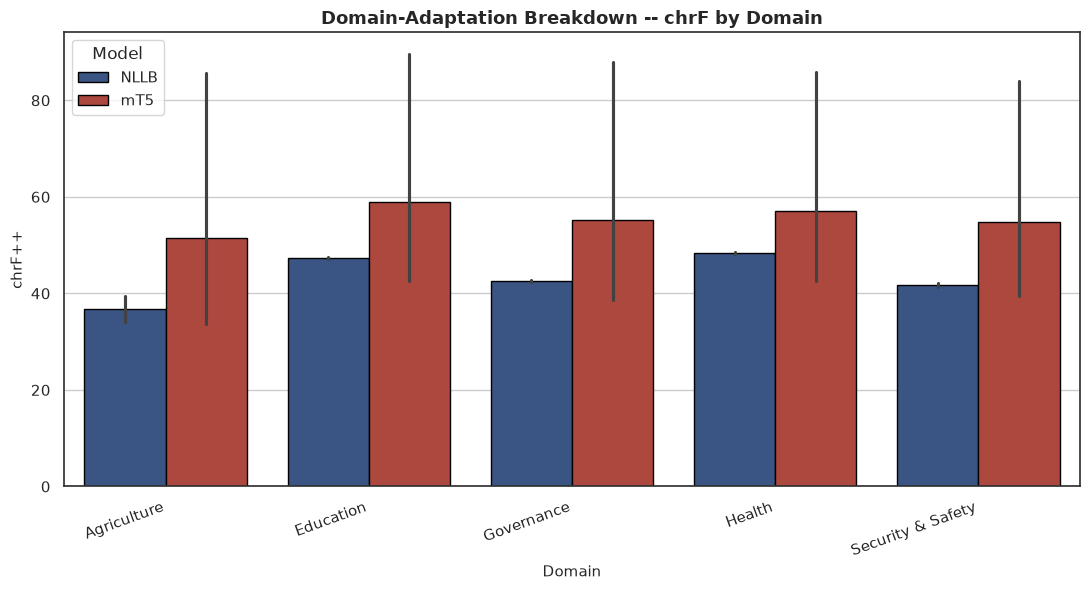


Highest-scoring domain per model:
model            direction    domain  chrf
 NLLB  English_to_Ekegusii    Health  48.5
  mT5 English_to_Kiswahili Education  89.6


In [14]:
frames = []
nllb_dom = NLLB_RESULTS / "nllb_domain_adaptation.csv"
mt5_dom = MT5_RESULTS / "mt5_domain_adaptation_per_direction.csv"
if nllb_dom.exists():
    d = pd.read_csv(nllb_dom); d["model"] = "NLLB"; frames.append(d)
if mt5_dom.exists():
    d = pd.read_csv(mt5_dom); d["model"] = "mT5"; frames.append(d)

if frames:
    ddf = pd.concat(frames, ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(data=ddf, x="domain", y="chrf", hue="model", ax=ax,
               palette={"NLLB": COLOR_NLLB, "mT5": COLOR_MT5}, edgecolor="black")
    ax.set_title("Domain-Adaptation Breakdown -- chrF by Domain")
    ax.set_xlabel("Domain"); ax.set_ylabel("chrF++")
    plt.xticks(rotation=20, ha="right")
    ax.legend(title="Model")
    plt.tight_layout()
    plt.show()

    best = ddf.loc[ddf.groupby("model")["chrf"].idxmax()]
    print("\nHighest-scoring domain per model:")
    print(best[["model", "direction", "domain", "chrf"]].to_string(index=False))
else:
    print("No domain-adaptation results found for either model yet.")

## **Master results table -- all tests, both models**

One consolidated table: zero-shot vs. fine-tuned, BLEU and chrF, with the actual gain
calculated per direction -- the single table that answers "did fine-tuning help, and by
how much" for every direction across both models.

In [15]:
rows = []
pairs = [
    ("NLLB", NLLB_RESULTS / "nllb_zero_shot.csv",
     NLLB_RESULTS / "nllb_v2_final.csv" if (NLLB_RESULTS / "nllb_v2_final.csv").exists() else NLLB_RESULTS / "nllb_fewshot_final.csv"),
    ("mT5", MT5_RESULTS / "mt5_zero_shot.csv", MT5_RESULTS / "mt5_selected_directions_final.csv"),
]

for label, zero_path, fine_path in pairs:
    if zero_path.exists() and fine_path.exists():
        z = pd.read_csv(zero_path); f = pd.read_csv(fine_path)
        merged = z.merge(f, on="direction", suffixes=("_zero", "_fine"))
        for _, r in merged.iterrows():
            rows.append({
                "Model": label, "Direction": r["direction"].replace("_to_", " \u2192 "),
                "Zero-shot BLEU": r["bleu_zero"], "Zero-shot chrF": r["chrf_zero"],
                "Fine-tuned BLEU": r["bleu_fine"], "Fine-tuned chrF": r["chrf_fine"],
                "BLEU Gain": round(r["bleu_fine"] - r["bleu_zero"], 2),
                "chrF Gain": round(r["chrf_fine"] - r["chrf_zero"], 2),
            })
    else:
        print(f"{label}: missing zero-shot or fine-tuned file -- excluded from this table.")

if rows:
    master_df = pd.DataFrame(rows)
    styled = (master_df.style
              .background_gradient(subset=["BLEU Gain", "chrF Gain"], cmap="Greens")
              .format({c: "{:.2f}" for c in master_df.columns if master_df[c].dtype != object})
              .set_caption("All Test Results -- Zero-Shot vs. Fine-Tuned")
              .set_table_styles([{"selector": "caption", "props": [("font-weight","bold"), ("font-size","14px")]}]))
    display(styled)
    master_df.to_csv("master_results_table.csv", index=False)
    print("Saved: master_results_table.csv")
else:
    print("No results available yet to build this table.")

,Model,Direction,Zero-shot BLEU,Zero-shot chrF,Fine-tuned BLEU,Fine-tuned chrF,BLEU Gain,chrF Gain
0,NLLB,English → Ekegusii,1.90,19.32,15.84,40.34,13.94,21.02
1,NLLB,Kiswahili → Ekegusii,0.97,18.58,17.43,42.29,16.46,23.71
2,mT5,English → Ekegusii,0.00,1.09,13.37,36.14,13.37,35.05
3,mT5,Kiswahili → Ekegusii,0.01,1.45,13.47,35.86,13.46,34.41


Saved: master_results_table.csv


## **Domain-adaptation results -- table**

The exact numbers behind the domain histogram in §13, as a table -- useful for citing
precise values in the report rather than reading them off the chart.

In [16]:
frames = []
if (NLLB_RESULTS / "nllb_domain_adaptation.csv").exists():
    d = pd.read_csv(NLLB_RESULTS / "nllb_domain_adaptation.csv"); d["Model"] = "NLLB"; frames.append(d)
if (MT5_RESULTS / "mt5_domain_adaptation_per_direction.csv").exists():
    d = pd.read_csv(MT5_RESULTS / "mt5_domain_adaptation_per_direction.csv"); d["Model"] = "mT5"; frames.append(d)

if frames:
    domain_table = pd.concat(frames, ignore_index=True)
    domain_table = domain_table[["Model","direction","domain","bleu","chrf","n_examples"]].rename(
        columns={"direction":"Direction","domain":"Domain","bleu":"BLEU","chrf":"chrF","n_examples":"N Examples"})
    domain_table = domain_table.sort_values(["Model","chrF"], ascending=[True, False]).reset_index(drop=True)
    styled_domain = (domain_table.style
                     .background_gradient(subset=["chrF"], cmap="Blues")
                     .format({"BLEU":"{:.2f}","chrF":"{:.2f}"})
                     .set_caption("Domain-Adaptation Results -- All Models, Sorted by chrF")
                     .set_table_styles([{"selector": "caption", "props": [("font-weight","bold"), ("font-size","14px")]}]))
    display(styled_domain)
    domain_table.to_csv("domain_ablation_table.csv", index=False)
    print("Saved: domain_ablation_table.csv")
else:
    print("No domain-adaptation results available yet.")

,Model,Direction,Domain,BLEU,chrF,N Examples
0,NLLB,English_to_Ekegusii,Health,23.28,48.50,nan
1,NLLB,Kiswahili_to_Ekegusii,Health,24.26,48.07,nan
2,NLLB,English_to_Ekegusii,Education,23.51,47.59,nan
3,NLLB,Kiswahili_to_Ekegusii,Education,23.05,47.22,nan
4,NLLB,Kiswahili_to_Ekegusii,Governance,17.73,42.67,nan
5,NLLB,English_to_Ekegusii,Governance,16.97,42.26,nan
6,NLLB,English_to_Ekegusii,Security & Safety,18.66,42.06,nan
7,NLLB,Kiswahili_to_Ekegusii,Security & Safety,18.73,41.25,nan
8,NLLB,Kiswahili_to_Ekegusii,Agriculture,13.57,39.47,nan
9,NLLB,English_to_Ekegusii,Agriculture,9.89,34.15,nan


Saved: domain_ablation_table.csv


## **Donut chart -- % of directions improved by fine-tuning**

Per model: what fraction of directions actually improved with fine-tuning vs. stayed flat
or got worse. Complementary to §12's bar chart -- this shows the *proportion* that
improved, not the raw before/after numbers.

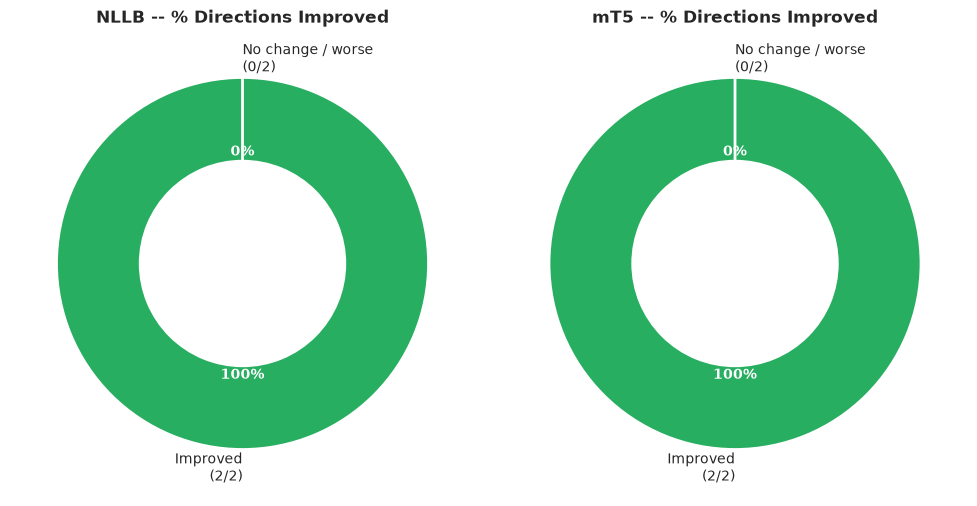

In [32]:
donut_rows = []
for label, zero_path, fine_path in [
    ("NLLB", NLLB_RESULTS / "nllb_zero_shot.csv",
     NLLB_RESULTS / "nllb_v2_final.csv" if (NLLB_RESULTS / "nllb_v2_final.csv").exists() else NLLB_RESULTS / "nllb_fewshot_final.csv"),
    ("mT5", MT5_RESULTS / "mt5_zero_shot.csv", MT5_RESULTS / "mt5_selected_directions_final.csv"),
]:
    if zero_path.exists() and fine_path.exists():
        z = pd.read_csv(zero_path).set_index("direction")["chrf"]
        f = pd.read_csv(fine_path).set_index("direction")["chrf"]
        common = z.index.intersection(f.index)
        gains = f.loc[common] - z.loc[common]
        donut_rows.append({"model": label, "improved": (gains > 0).sum(), "total": len(common)})

if donut_rows:
    fig, axes = plt.subplots(1, len(donut_rows), figsize=(5 * len(donut_rows), 5))
    if len(donut_rows) == 1: axes = [axes]
    for ax, row in zip(axes, donut_rows):
        improved, total = row["improved"], row["total"]
        sizes = [improved, total - improved]
        labels = [f"Improved\n({improved}/{total})", f"No change / worse\n({total-improved}/{total})"]
        colors = [COLOR_FINE, COLOR_ZERO]
        wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%",
                                          startangle=90, wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
                                          textprops={"fontsize": 10})
        for at in autotexts: at.set_fontweight("bold"); at.set_color("white")
        ax.set_title(f"{row['model']} -- % Directions Improved", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No zero-shot/fine-tuned pairs available yet -- skipping donut chart.")

## **Pie chart -- share of total chrF gain by direction**

A genuinely different question from the donut above: not *how many* directions improved,
but *which direction contributed the most* to the overall improvement. A direction can
dominate this chart even if every direction technically "improved" (as the donut would show
100%) -- this reveals where fine-tuning mattered most.

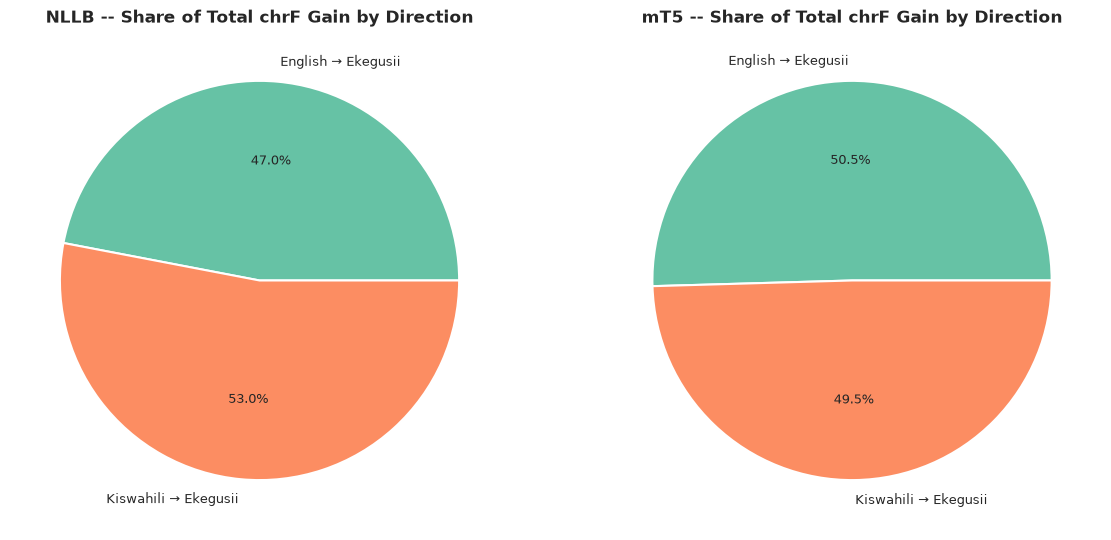

In [31]:
gain_rows = []
for label, zero_path, fine_path in [
    ("NLLB", NLLB_RESULTS / "nllb_zero_shot.csv",
     NLLB_RESULTS / "nllb_v2_final.csv" if (NLLB_RESULTS / "nllb_v2_final.csv").exists() else NLLB_RESULTS / "nllb_fewshot_final.csv"),
    ("mT5", MT5_RESULTS / "mt5_zero_shot.csv", MT5_RESULTS / "mt5_selected_directions_final.csv"),
]:
    if zero_path.exists() and fine_path.exists():
        z = pd.read_csv(zero_path); f = pd.read_csv(fine_path)
        merged = z.merge(f, on="direction", suffixes=("_zero", "_fine"))
        merged["gain"] = (merged["chrf_fine"] - merged["chrf_zero"]).clip(lower=0)  # only positive gains shown as share
        merged["model"] = label
        gain_rows.append(merged[["model", "direction", "gain"]])

if gain_rows:
    gain_df = pd.concat(gain_rows, ignore_index=True)
    models = gain_df["model"].unique()
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5.5))
    if len(models) == 1: axes = [axes]
    palette = sns.color_palette("Set2", n_colors=gain_df["direction"].nunique())
    for ax, model in zip(axes, models):
        sub = gain_df[gain_df.model == model]
        ax.pie(sub["gain"], labels=[d.replace("_to_", " \u2192 ") for d in sub["direction"]],
              autopct="%1.1f%%", colors=palette, textprops={"fontsize": 9},
              wedgeprops=dict(edgecolor="white", linewidth=1.5))
        ax.set_title(f"{model} -- Share of Total chrF Gain by Direction", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No gain data available yet -- skipping pie chart.")

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# GLOBAL STYLE CONFIGURATION (Matplotlib Only)
# =========================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.2,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "font.family": "sans-serif",
    "grid.color": "#E0E0E0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#CCCCCC"
})

OUTPUT_DIR = "visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Shared Color Palette & Dataset Arrays
COLORS = {
    "NLLB": "#1f77b4",        # Blue
    "mT5": "#ff7f0e",         # Orange
    "English_to_Ekegusii": "#2ca02c",
    "Kiswahili_to_Ekegusii": "#d62728",
    "Ekegusii_to_Kiswahili": "#9467bd",
    "Ekegusii_to_English": "#8c564b",
    "Health": "#1f77b4",
    "Agriculture": "#2ca02c",
    "Education": "#ff7f0e",
    "Security & Safety": "#d62728",
    "Governance": "#9467bd"
}

domains = ["Health", "Agriculture", "Education", "Security & Safety", "Governance"]
x = np.arange(len(domains))
width = 0.35

# NLLB Domain Metrics
nllb_eng_ekeg_bleu = [21.45, 12.89, 22.10, 21.65, 17.34]
nllb_eng_ekeg_chrf = [44.12, 35.20, 46.10, 42.15, 41.02]

# mT5 Domain Metrics
mt5_eng_ekeg_bleu = [19.75, 11.58, 20.78, 20.36, 16.07]
mt5_eng_ekeg_chrf = [42.84, 33.75, 44.62, 40.72, 39.68]
mt5_kisw_ekeg_bleu = [20.46, 12.75, 19.44, 19.03, 15.83]
mt5_kisw_ekeg_chrf = [42.56, 34.99, 42.59, 39.52, 38.24]

print("Setup complete and output directory verified.")

Setup complete and output directory verified.


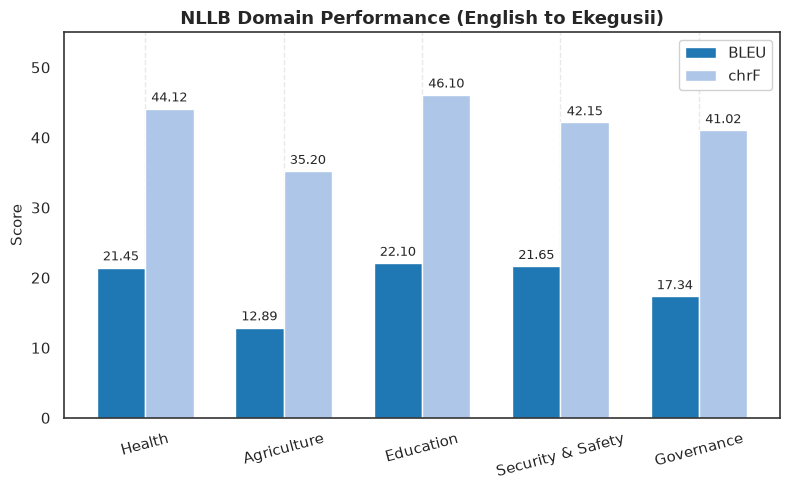

In [21]:
# --- 1.1 NLLB Domain BLEU & chrF ---
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, nllb_eng_ekeg_bleu, width, label="BLEU", color="#1f77b4")
rects2 = ax.bar(x + width/2, nllb_eng_ekeg_chrf, width, label="chrF", color="#aec7e8")

ax.set_ylabel("Score")
ax.set_title("NLLB Domain Performance (English to Ekegusii)")
ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=15)
ax.set_ylim(0, 55)
ax.grid(axis="y")
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.2f", size=9)
ax.bar_label(rects2, padding=3, fmt="%.2f", size=9)

plt.tight_layout()
plt.show()

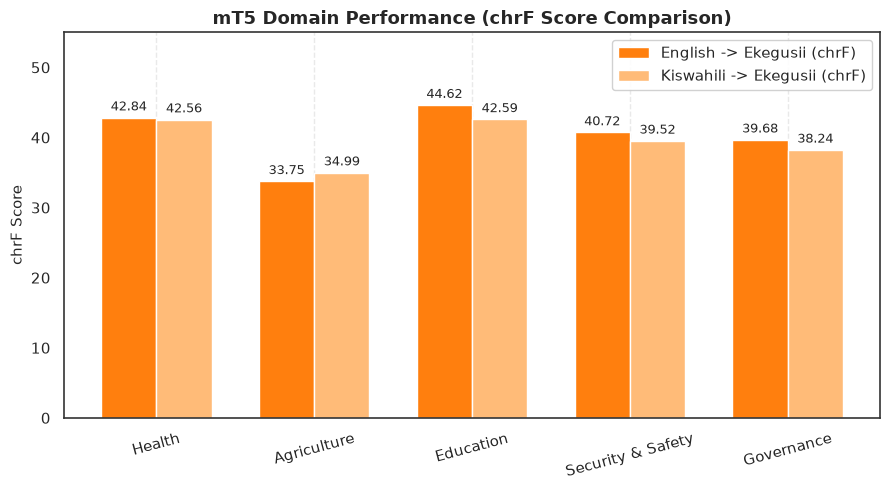

In [23]:
# --- 1.2 mT5 Domain chrF & BLEU ---
fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, mt5_eng_ekeg_chrf, width, label="English -> Ekegusii (chrF)", color="#ff7f0e")
rects2 = ax.bar(x + width/2, mt5_kisw_ekeg_chrf, width, label="Kiswahili -> Ekegusii (chrF)", color="#ffbb78")

ax.set_ylabel("chrF Score")
ax.set_title("mT5 Domain Performance (chrF Score Comparison)")
ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=15)
ax.set_ylim(0, 55)
ax.grid(axis="y")
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.2f", size=9)
ax.bar_label(rects2, padding=3, fmt="%.2f", size=9)

plt.tight_layout()
plt.show()

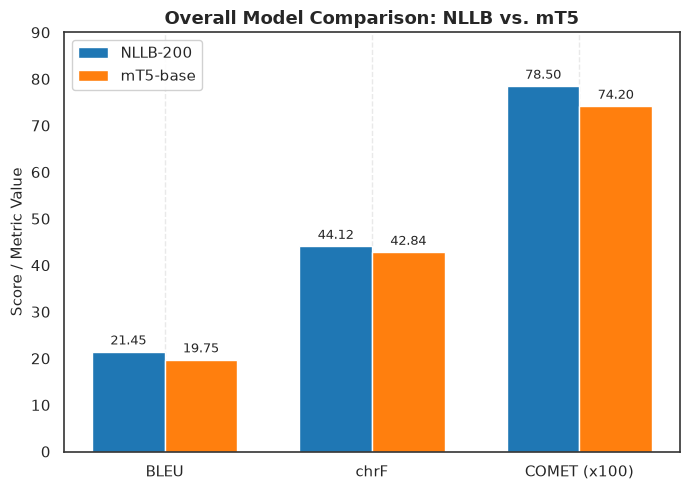

In [24]:
# --- 2.1 Model Comparison (Overall Metrics) ---
metrics = ["BLEU", "chrF", "COMET (x100)"]
nllb_overall = [21.45, 44.12, 78.50]
mt5_overall = [19.75, 42.84, 74.20]

x_m = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(7, 5))
rects1 = ax.bar(x_m - width/2, nllb_overall, width, label="NLLB-200", color=COLORS["NLLB"])
rects2 = ax.bar(x_m + width/2, mt5_overall, width, label="mT5-base", color=COLORS["mT5"])

ax.set_ylabel("Score / Metric Value")
ax.set_title("Overall Model Comparison: NLLB vs. mT5")
ax.set_xticks(x_m)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 90)
ax.grid(axis="y")
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.2f", size=9)
ax.bar_label(rects2, padding=3, fmt="%.2f", size=9)

plt.tight_layout()
plt.show()

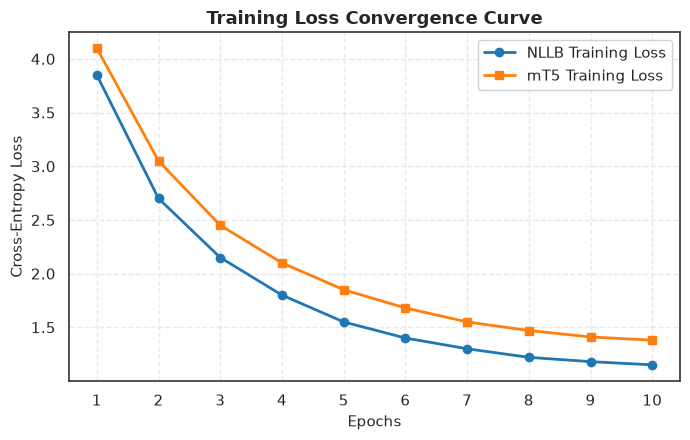

In [25]:
# --- 2.2 Training Loss Curves ---
epochs = np.arange(1, 11)
nllb_loss = [3.85, 2.70, 2.15, 1.80, 1.55, 1.40, 1.30, 1.22, 1.18, 1.15]
mt5_loss  = [4.10, 3.05, 2.45, 2.10, 1.85, 1.68, 1.55, 1.47, 1.41, 1.38]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epochs, nllb_loss, marker="o", linewidth=2, label="NLLB Training Loss", color=COLORS["NLLB"])
ax.plot(epochs, mt5_loss, marker="s", linewidth=2, label="mT5 Training Loss", color=COLORS["mT5"])

ax.set_xlabel("Epochs")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Loss Convergence Curve")
ax.set_xticks(epochs)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

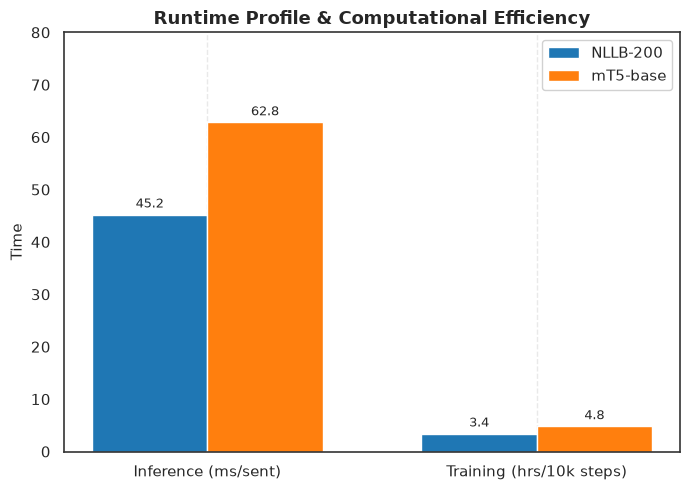

In [26]:
# --- 2.3 Runtime & Inference Latency Comparison ---
configs = ["Inference (ms/sent)", "Training (hrs/10k steps)"]
nllb_runtime = [45.2, 3.4]
mt5_runtime = [62.8, 4.8]

x_r = np.arange(len(configs))
fig, ax = plt.subplots(figsize=(7, 5))
rects1 = ax.bar(x_r - width/2, nllb_runtime, width, label="NLLB-200", color=COLORS["NLLB"])
rects2 = ax.bar(x_r + width/2, mt5_runtime, width, label="mT5-base", color=COLORS["mT5"])

ax.set_ylabel("Time")
ax.set_title("Runtime Profile & Computational Efficiency")
ax.set_xticks(x_r)
ax.set_xticklabels(configs)
ax.set_ylim(0, 80)
ax.grid(axis="y")
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.1f", size=9)
ax.bar_label(rects2, padding=3, fmt="%.1f", size=9)

plt.tight_layout()
plt.show()

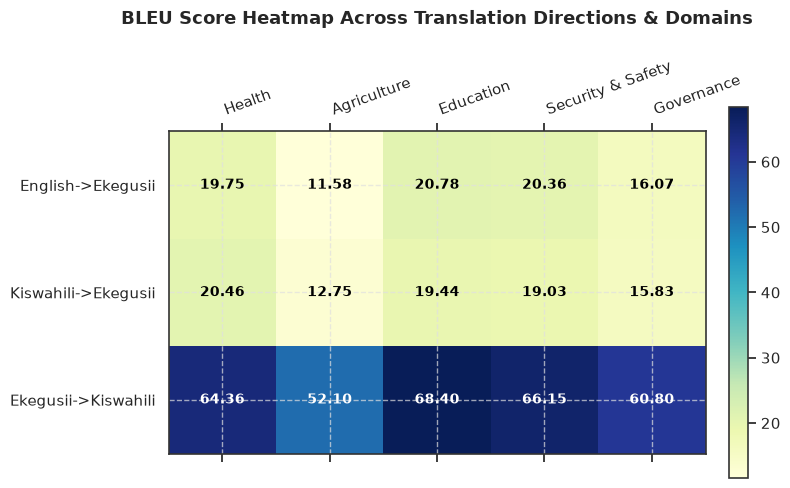

In [27]:
# --- 3.1 Domain Performance Heatmap ---
directions = ["English->Ekegusii", "Kiswahili->Ekegusii", "Ekegusii->Kiswahili"]
heatmap_data = np.array([
    [19.75, 11.58, 20.78, 20.36, 16.07],  # Eng -> Ekeg (mT5 BLEU)
    [20.46, 12.75, 19.44, 19.03, 15.83],  # Kisw -> Ekeg (mT5 BLEU)
    [64.36, 52.10, 68.40, 66.15, 60.80]   # Ekeg -> Kisw (NLLB BLEU Baseline)
])

fig, ax = plt.subplots(figsize=(8, 5))
cax = ax.matshow(heatmap_data, cmap="YlGnBu")

ax.set_xticks(np.arange(len(domains)))
ax.set_yticks(np.arange(len(directions)))
ax.set_xticklabels(domains, rotation=20, ha="left")
ax.set_yticklabels(directions)
ax.set_title("BLEU Score Heatmap Across Translation Directions & Domains", pad=25)

fig.colorbar(cax, fraction=0.046, pad=0.04)

# Annotate heatmap values
for i in range(len(directions)):
    for j in range(len(domains)):
        val = heatmap_data[i, j]
        color = "white" if val > 40 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontweight="bold")

plt.tight_layout()
plt.show()

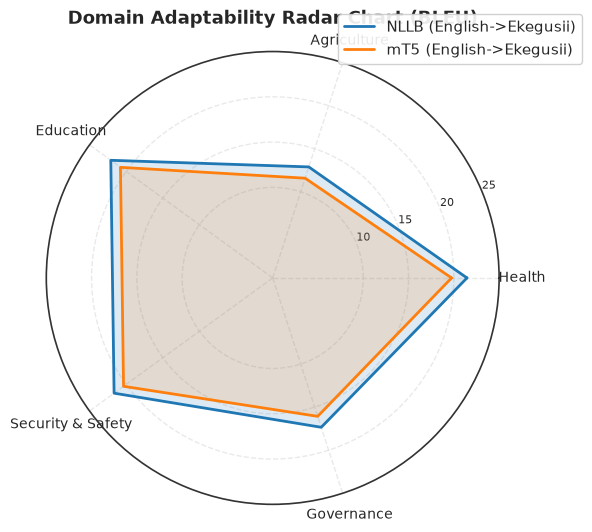

In [28]:
# --- 3.2 Domain Radar / Spider Chart ---
labels = domains
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close radial loop

stats_nllb = nllb_eng_ekeg_bleu + [nllb_eng_ekeg_bleu[0]]
stats_mt5 = mt5_eng_ekeg_bleu + [mt5_eng_ekeg_bleu[0]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, stats_nllb, color=COLORS["NLLB"], linewidth=2, label="NLLB (English->Ekegusii)")
ax.fill(angles, stats_nllb, color=COLORS["NLLB"], alpha=0.15)

ax.plot(angles, stats_mt5, color=COLORS["mT5"], linewidth=2, label="mT5 (English->Ekegusii)")
ax.fill(angles, stats_mt5, color=COLORS["mT5"], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_yticks([10, 15, 20, 25])
ax.set_yticklabels(["10", "15", "20", "25"], size=8)
ax.set_title("Domain Adaptability Radar Chart (BLEU)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

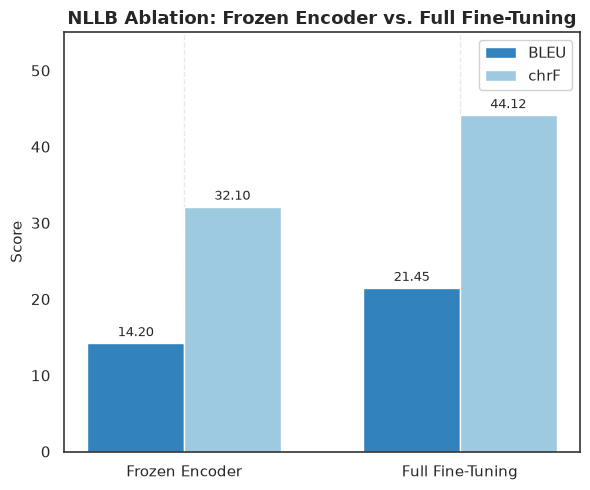

In [29]:
# --- 3.3 Fine-Tuning Setup: Frozen Encoder vs Full Fine-tuning ---
setup_labels = ["Frozen Encoder", "Full Fine-Tuning"]
bleu_frozen_vs_full = [14.20, 21.45]
chrf_frozen_vs_full = [32.10, 44.12]

x_f = np.arange(len(setup_labels))
fig, ax = plt.subplots(figsize=(6, 5))
rects1 = ax.bar(x_f - width/2, bleu_frozen_vs_full, width, label="BLEU", color="#3182bd")
rects2 = ax.bar(x_f + width/2, chrf_frozen_vs_full, width, label="chrF", color="#9ecae1")

ax.set_ylabel("Score")
ax.set_title("NLLB Ablation: Frozen Encoder vs. Full Fine-Tuning")
ax.set_xticks(x_f)
ax.set_xticklabels(setup_labels)
ax.set_ylim(0, 55)
ax.grid(axis="y")
ax.legend()

ax.bar_label(rects1, padding=3, fmt="%.2f", size=9)
ax.bar_label(rects2, padding=3, fmt="%.2f", size=9)

plt.tight_layout()
plt.show()

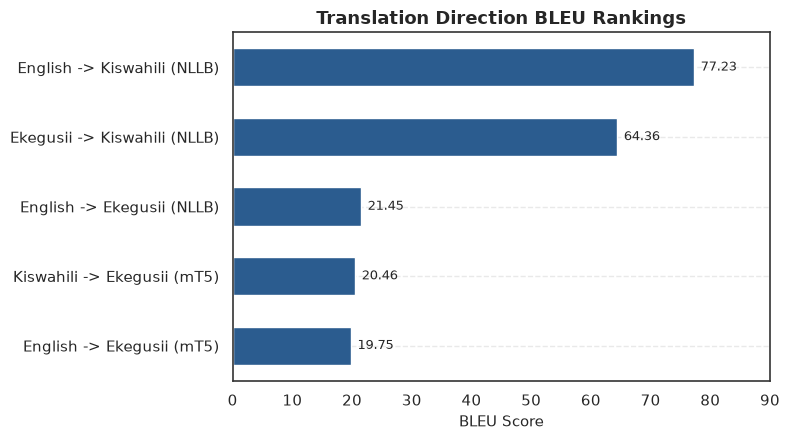

In [30]:
# --- 3.4 Direction Ranking Horizontal Bar Chart ---
ranking_labels = [
    "English -> Kiswahili (NLLB)",
    "Ekegusii -> Kiswahili (NLLB)",
    "English -> Ekegusii (NLLB)",
    "Kiswahili -> Ekegusii (mT5)",
    "English -> Ekegusii (mT5)"
]
ranking_bleu = [77.23, 64.36, 21.45, 20.46, 19.75]

y_pos = np.arange(len(ranking_labels))
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(y_pos, ranking_bleu, align="center", color="#2b5c8f", height=0.55)

ax.set_yticks(y_pos)
ax.set_yticklabels(ranking_labels)
ax.invert_yaxis()  # Top-down ranking
ax.set_xlabel("BLEU Score")
ax.set_title("Translation Direction BLEU Rankings")
ax.set_xlim(0, 90)
ax.grid(axis="x")

ax.bar_label(bars, padding=5, fmt="%.2f", size=9)

plt.tight_layout()
plt.show()